In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split   
df=pd.read_csv(r'preprocessed_data_1.csv')
print(df.head())

   Employee_ID  Age  Experience_Years Education  Department  Job_Level  \
0        10001   59                34  Bachelor   Marketing          9   
1        10002   49                29  Bachelor          HR          9   
2        10003   35                10  Bachelor          IT          4   
3        10004   28                 3    Master  Operations          1   
4        10005   41                18    Master          IT          5   

   Performance_Rating  Projects_Completed  Certifications  Weekly_Work_Hours  \
0                 3.7                  30              13               38.1   
1                 3.2                  25              10               48.3   
2                 3.1                  13               4               41.7   
3                 3.1                   7               3               41.8   
4                 2.6                  18               7               47.2   

  Remote_Work City_Tier  Job_Satisfaction  Salary_LPA Salary_Status  
0   

In [2]:
df.columns

Index(['Employee_ID', 'Age', 'Experience_Years', 'Education', 'Department',
       'Job_Level', 'Performance_Rating', 'Projects_Completed',
       'Certifications', 'Weekly_Work_Hours', 'Remote_Work', 'City_Tier',
       'Job_Satisfaction', 'Salary_LPA', 'Salary_Status'],
      dtype='str')

In [3]:
df.dtypes

Employee_ID             int64
Age                     int64
Experience_Years        int64
Education                 str
Department                str
Job_Level               int64
Performance_Rating    float64
Projects_Completed      int64
Certifications          int64
Weekly_Work_Hours     float64
Remote_Work               str
City_Tier                 str
Job_Satisfaction        int64
Salary_LPA            float64
Salary_Status             str
dtype: object

Intercept:  [-40.42864298]
Coefficients:  [[ 0.06775272  0.63530571  3.04980866  1.06228693  0.13316289  0.30485284
   0.03136504  0.39479111 -1.85341416 -2.15224617  2.0771411   2.83282479
  -1.20969987  0.61870778 -0.28329413 -0.72655978 -0.44956743  0.37255354
  -1.13911785 -2.23407322]]

Actual vs Predicted Salary
   Performance_Rating  Actual Salary_LPA  Actual Salary Class  \
0                 3.2              22.85                    0   
1                 3.5              47.43                    1   
2                 4.2              50.00                    1   
3                 3.7              37.97                    1   
4                 2.9              45.91                    1   
5                 3.6              33.74                    0   
6                 3.0              17.59                    0   
7                 5.0              19.79                    0   
8                 4.2              32.69                    0   
9                 3.3         

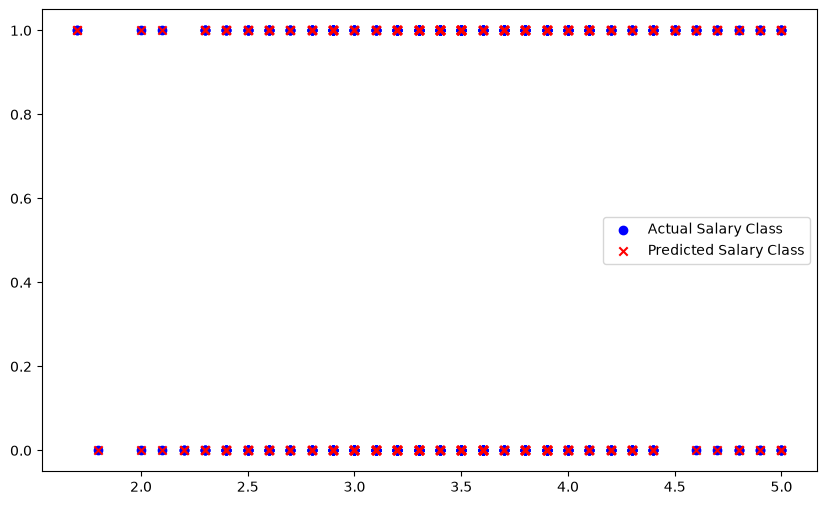

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
df = pd.read_csv("preprocessed_data_1.csv")
median_salary = df["Salary_LPA"].median()

df["Salary_Class"] = (
    df["Salary_LPA"] >= median_salary
).astype(int)

X = df[
    [
        "Age",
        "Experience_Years",
        "Education",
        "Department",
        "Job_Level",
        "Performance_Rating",
        "Projects_Completed",
        "Certifications",
        "Weekly_Work_Hours",
        "Remote_Work",
        "City_Tier",
        "Job_Satisfaction"
    ]
]

y = df["Salary_Class"]
X = pd.get_dummies(
    X,
    drop_first=True
)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)

y_pred = model.predict(X_test)
results = pd.DataFrame({
    "Performance_Rating": X_test["Performance_Rating"].values,
    "Actual Salary_LPA": df.loc[X_test.index, "Salary_LPA"].values,
    "Actual Salary Class": y_test.values,
    "Predicted Salary Class": y_pred
})

print("\nActual vs Predicted Salary")
print(results.head(10))

plt.figure(figsize=(10, 6))
plt.scatter(
    X_test["Performance_Rating"],
    y_test,
    color="blue",
    label="Actual Salary Class"
)
plt.scatter(
    X_test["Performance_Rating"],
    y_pred,
    color="red",
    marker="x",
    label="Predicted Salary Class"
)
plt.xlabel = ("Performance_Rating")
plt.ylabel = ("Salary Class")
plt.title = ("Actual vs Predicted Salary Class")
plt.legend()
plt.show()


In [5]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , f1_score , recall_score , precision_score

In [6]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

confusion_matrix = confusion_matrix(y_test,y_pred)
print("Confusion matrix: ",confusion_matrix)

classification_report = classification_report(y_test,y_pred)
print("Classification_report: ",classification_report)

f1_score = f1_score(y_test,y_pred)
print("f1_score: ",f1_score)

recall_score = recall_score(y_test,y_pred)
print("recall_score:",recall_score)

precision_score = precision_score(y_test,y_pred)
print("precision_score: ",precision_score)

Accuracy: 0.984
Confusion matrix:  [[247   3]
 [  5 245]]
Classification_report:                precision    recall  f1-score   support

           0       0.98      0.99      0.98       250
           1       0.99      0.98      0.98       250

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500

f1_score:  0.9839357429718876
recall_score: 0.98
precision_score:  0.9879032258064516


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



mean_absolute_error = mean_absolute_error(y_test, y_pred)

mean_squared_error = mean_squared_error(y_test, y_pred)

rmse = mean_squared_error ** 0.5

r2 = r2_score(y_test, y_pred)
print("MAE :", mean_absolute_error)
print("MSE :", mean_squared_error)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.016
MSE : 0.016
RMSE: 0.12649110640673517
R2 Score: 0.9359999999999999
